# 데이터 전처리 실습

- 타이타닉 생존자 예측 문제 데이터의 전처리

<img src="https://raw.githubusercontent.com/data-labs/image/main/%E1%84%89%E1%85%B3%E1%84%8F%E1%85%B3%E1%84%85%E1%85%B5%E1%86%AB%E1%84%89%E1%85%A3%E1%86%BA%202021-01-07%20%E1%84%8B%E1%85%A9%E1%84%92%E1%85%AE%2010.36.15.png?raw=1" width=400 align='left'>

# import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# 맥에서 레티나 디스플레이 사용 설정
%config InlineBackend.figure_format = 'retina'

# 데이터
- 타이타닉 탑승자 개인별 데이터를 보고 생존 여부를 예측하는 예제 데이터

- Survival - 생존여부(타겟변수 y): 0 = No, 1 = Yes
- Pclass - 티켓 등급: 1 = 1st, 2 = 2nd, 3 = 3rd
- Sex - 성별: male, female
- Age - 나이
- SibSp - 동승한 형제, 배우자 수
- Parch - 부모와 자녀의 수
- Ticket - 티켓 번호
- Fare - 승선 요금
- Cabin - 캐빈(객실) 번호
- Embarked - 승선한 항구: C = Cherbourg, Q = Queenstown, S = Southampton

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/StillWork/data/master/titanic_train.csv")
print(data.shape)
data[:3]

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S



## 데이터 전처리

- 데이터 클리닝 - 결측치 처리, 틀린값 처리
- 이상치 처리 - 이상치 탐지 및 제거
- 데이터 변환 - 로그 변환, 카테고리 인코딩 등
- 스케일링 - 여러 변수 값의 범위를 동등한 조건으로 맞추는 것: 표준 스케일링, min-max 스케일링

## 데이터 기본 정보
- info()를 사용
- 컬럼 이름, 컬럼수(특성 수), 샘플수를 파악한다
- 카테고리형 타입(object)과 숫자형 타입(int, float)을 파악한다
  - 숫자 타입도 연속적인 값을 갖는 아나로그형과 카테고리형이 있다
  - 아래에서 Pclass는 선실 등급을 나타내는 카테고리 변수이다

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 결측치 처리

- 결측치를 처리하는 방법은 크게 세 가지가 있다
  - 결측치가 포함된 샘플(행)을 버린다
  - 결측치를 적절한 값으로 대체한다
  - 결측치 처리를 다음 분석 단계로 넘긴다. 즉, 결측치를 그대로 둔다

- 특정 컬럼에 결측치가 너무 많은 경우 컬럼 자체를 사용하지 않는 방법도 있다
  - 샘플(행) 삭제를 하기 전에 컬럼 삭제를 먼저 고려해야 한다


<img src="https://raw.githubusercontent.com/data-labs/image/main/%E1%84%89%E1%85%B3%E1%84%8F%E1%85%B3%E1%84%85%E1%85%B5%E1%86%AB%E1%84%89%E1%85%A3%E1%86%BA%202021-01-06%20%E1%84%8B%E1%85%A9%E1%84%92%E1%85%AE%2011.01.24.png?raw=1" width=320 align='left'>

## 컬럼별 결측치 수 확인

In [4]:
# 사본 사용
df = data.copy()
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## 컬럼 미사용

### Cabin(객실명)
- Cabin은 객실명으로, 의미있는 정보가 아니고, 결측치가 많고(687개), 종류가 다양하므로(147종류) 컬럼 자체를 사용하지 않기로 한다

In [5]:
print("Cabin 종류:", df.Cabin.nunique())
df.Cabin.value_counts()[:5]

Cabin 종류: 147


,count
Cabin,
G6,4
C23 C25 C27,4
B96 B98,4
F2,3
D,3


### Ticket(티켓명)
- 681 종류나 되며 분석에 큰 의미가 없는 것으로 보인다. 분석에 사용하지 않는다. 즉, 컬럼 삭제를 하겠다

In [6]:
## Ticket 보기

print("Ticket 종류:", df.Ticket.nunique())
df.Ticket.value_counts()[:5]

Ticket 종류: 681


,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6


### PassengerId, Name

- 일렬번호와 이름은 분석에 의미가 없으므로 사용하지 않는다

In [7]:
## 사용하지 않을 컬럼 4개를 삭제한 데이터프레임을 만든다

df = df[df.columns.difference(['PassengerId','Name','Ticket','Cabin'])]
df[:5]

,Age,Embarked,Fare,Parch,Pclass,Sex,SibSp,Survived
0,22.0,S,7.2500,0,3,male,1,0
1,38.0,C,71.2833,0,1,female,1,1
2,26.0,S,7.9250,0,3,female,0,1
3,35.0,S,53.1000,0,1,female,1,1
4,35.0,S,8.0500,0,3,male,0,0


## 결측치 대체

### 나이

- Age(나이)는 결측치가 많으나, 의미 있는 정보이므로 삭제하지 않고 다른 값으로 대체한다 (평균치 사용)

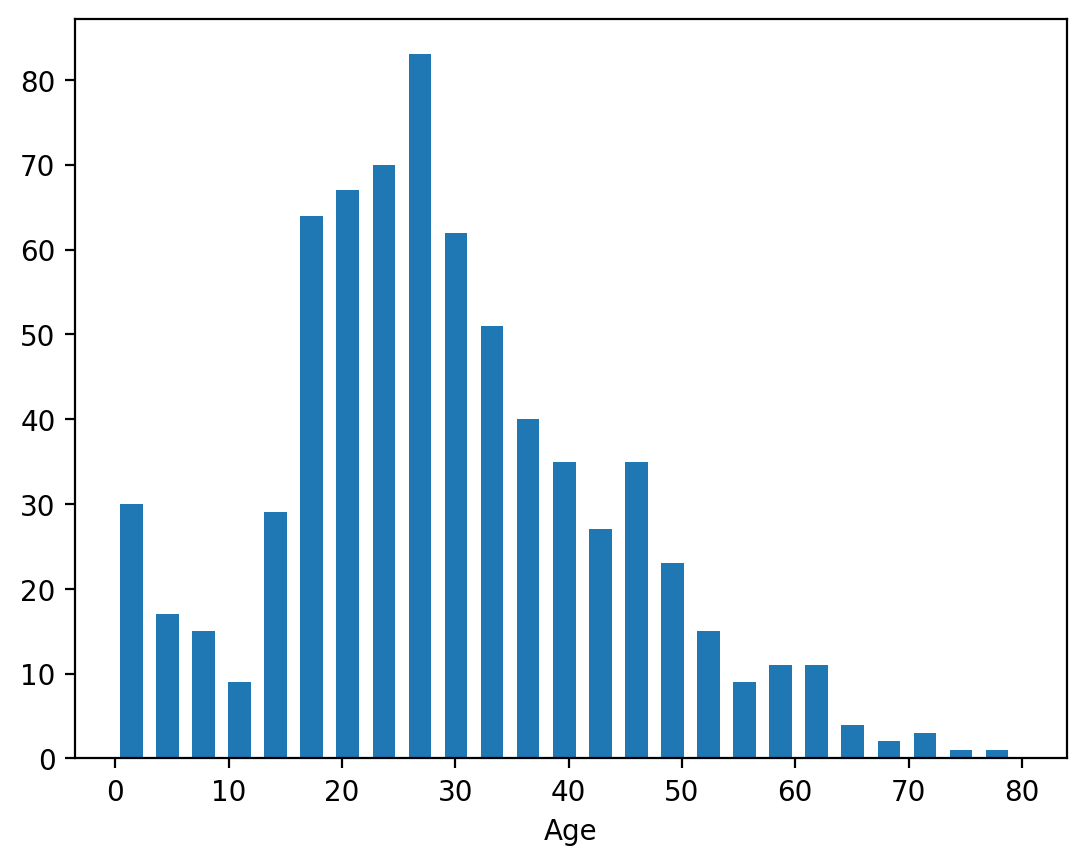

In [8]:
## Age (나이) 분포 보기

plt.hist(df.Age, bins=25, width=2)
plt.xlabel('Age')
plt.show()

/tmp/ipykernel_6603/1131926555.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Age.fillna(df.Age.mean(), inplace=True)


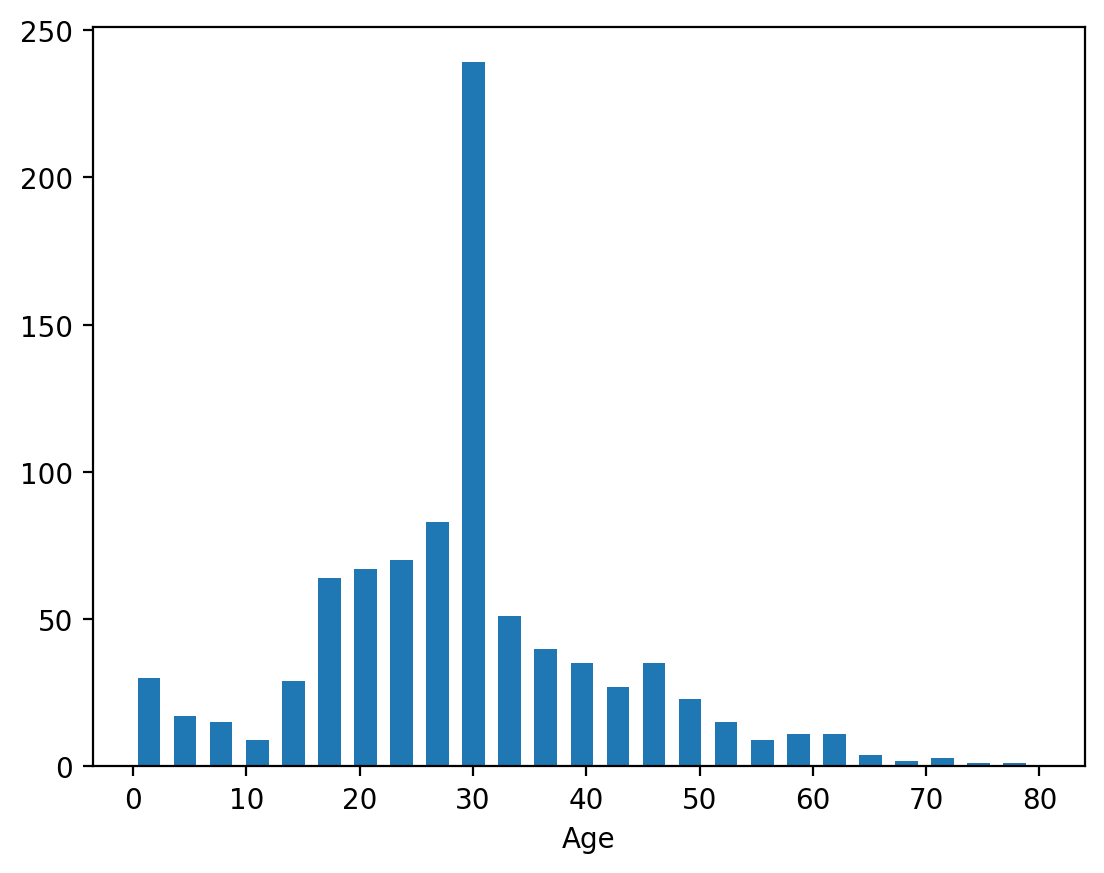

In [9]:
## 결측치를 평균 나이로 대체 (대체한 것을 즉시 반영했다)

df.Age.fillna(df.Age.mean(), inplace=True)
plt.hist(df.Age, bins=25, width=2)
plt.xlabel('Age')
plt.show()

### 항구명
- 항구 데이터(Embarked)는 결측치가 2개 뿐이고 다른 값으로 대체하기가 어려우므로 샘플을 삭제한다

In [10]:
## Embarked (항구명) 결측치가 있는 두 샘플은 삭제한다

print(df.shape)
df = df[~df["Embarked"].isnull()]
print(df.shape)

(891, 8)
(889, 8)


# 데이터 변환
- 카테고리 변수와 아나로그 변수로 나누어 처리한다
- 카테고리 변수는 일반적으로 원핫 인코딩으로 표현한다
- 아나로그 변수는 로그변환, 역수변환 등을 하거나 카테고리 변수로 변환하기도 한다

## 카테고리 변수

- 원핫(one-hot) 인코딩으로 변환한다
- get_dummies() 사용

### 선실 등급
- 숫자로 표현되어 있으나 카테고리를 나타낸다 (3가지 등급)

In [11]:
# 선실 등급은 3가지 등급을 나타내는 카테고리 변수임
df.Pclass.value_counts()

,count
Pclass,
3,491
1,214
2,184


### 성별
- 성별도 카테고리 변수이며 원핫 인코딩으로 변환한다

In [12]:
df.Sex.value_counts()

,count
Sex,
male,577
female,312


### 항구명
- 세가지 항구명도 카테고리 변수이며 원핫 인코딩으로 변환한다

In [13]:
df["Embarked"].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [14]:
## 선실등급, 성별, 항구명을 원핫 인코딩한다

df = pd.get_dummies(df, columns=['Pclass','Sex','Embarked'])
df[:5]

,Age,Fare,Parch,SibSp,Survived,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,22.0,7.2500,0,1,0,False,False,True,False,True,False,False,True
1,38.0,71.2833,0,1,1,True,False,False,True,False,True,False,False
2,26.0,7.9250,0,0,1,False,False,True,True,False,False,False,True
3,35.0,53.1000,0,1,1,True,False,False,True,False,False,False,True
4,35.0,8.0500,0,0,0,False,False,True,False,True,False,False,True


## 연속형 변수

### 요금

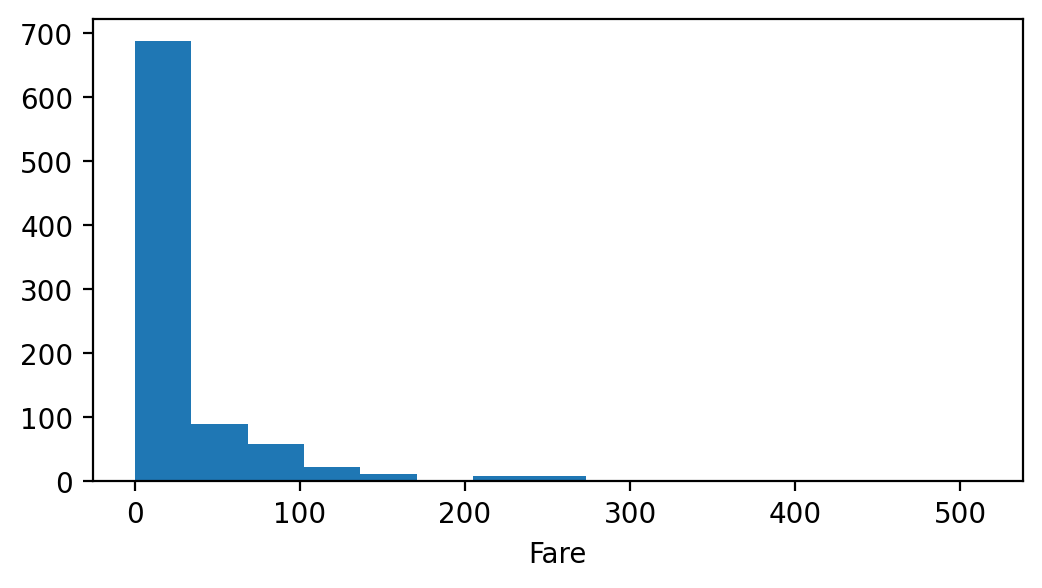

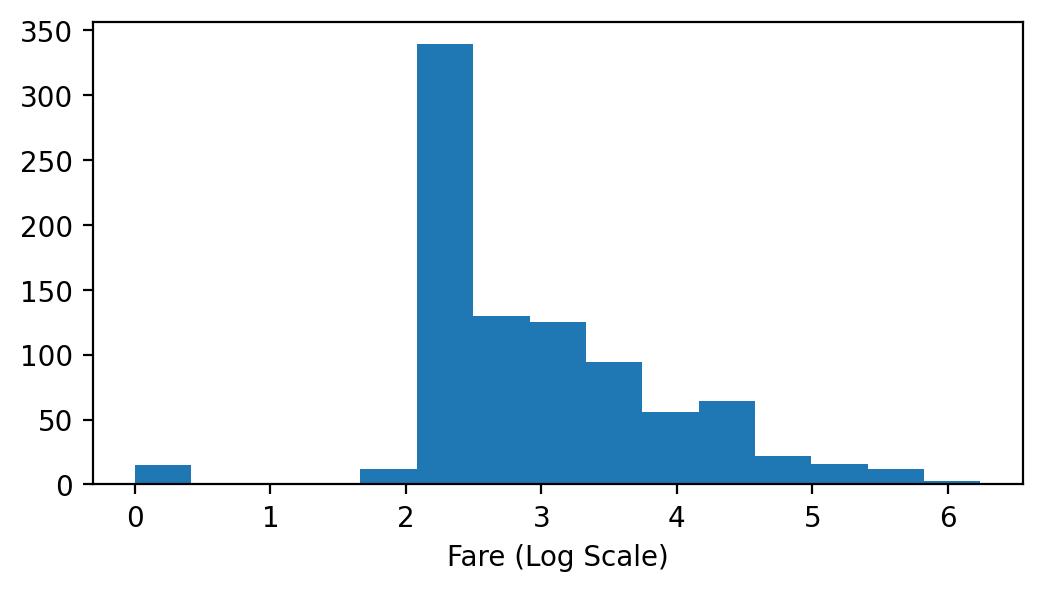

In [15]:
## 돈과 관련된 데이터는 로그를 취하면 정규 분포처럼 보인다

plt.figure(figsize=(6,3))
plt.hist(df.Fare, bins=15)
plt.xlabel('Fare')
plt.show()
plt.figure(figsize=(6,3))
plt.hist(np.log(df.Fare+1), bins=15)
plt.xlabel('Fare (Log Scale)')
plt.show()

In [16]:
## 요금(Fare)은 로그를 취한 값을 사용한다

df["Fare"] = np.log(df.Fare +1)
df[:5]

,Age,Fare,Parch,SibSp,Survived,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,22.0,2.110213,0,1,0,False,False,True,False,True,False,False,True
1,38.0,4.280593,0,1,1,True,False,False,True,False,True,False,False
2,26.0,2.188856,0,0,1,False,False,True,True,False,False,False,True
3,35.0,3.990834,0,1,1,True,False,False,True,False,False,False,True
4,35.0,2.202765,0,0,0,False,False,True,False,True,False,False,True


### 기타 변수
- 형제/동반자(sibling/spouse), 부모/자녀(parent/child) 수는 그대로 사용한다
- 즉, 별도의 변환은 하지 않는다

<Axes: >

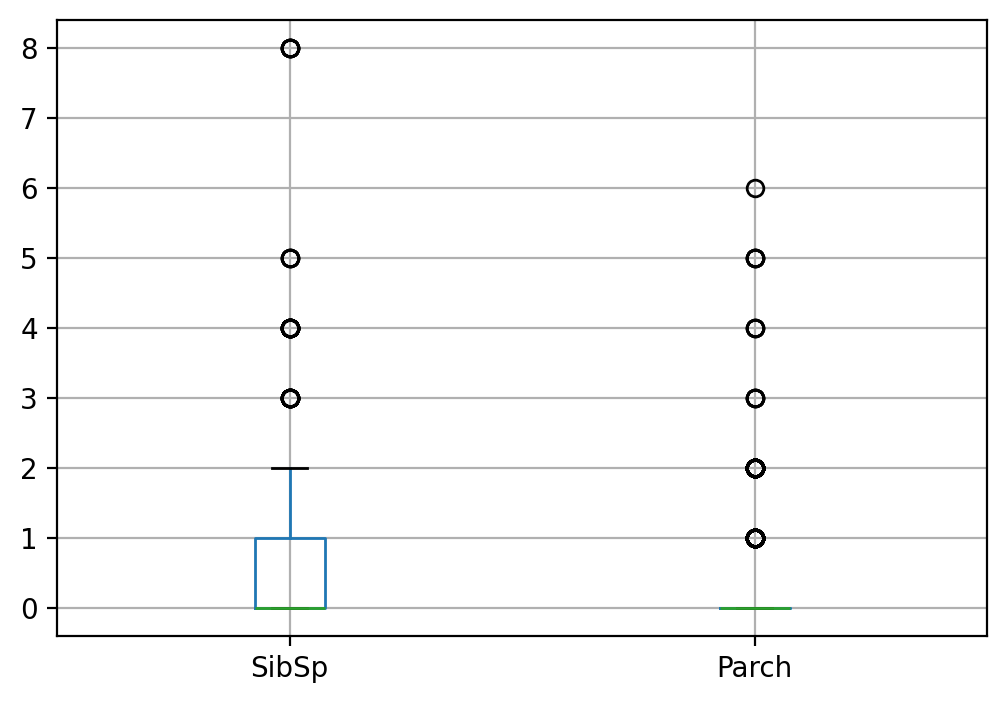

In [17]:
## 박스 플롯으로 데이터의 전체적인 값의 범위를 파악할 수 있다
## 'Pclass','SibSp','Parch' 의 범위 보기

plt.figure(figsize=(6,4))
df[['SibSp','Parch']].boxplot()

### 스케일링
- 일반적으로 연속형, 아나로그 값은 스케일링을 하는 것이 안전하다
- 결정트리, 랜덤 포레스트 등 트리 계열의 모델에서는 스케일링을 하지 않아도 되지만 선형모델, 신경망 모델 등에서 스케일링을 해야 한다
- 기본적으로는 표준 스케일링을 하며, 최대값과 최소값의 범위가 분명히 한정되어 있을 때는 min-max 스케일링도 사용한다

In [18]:
## 연속형 변수에 표준 스케일링을 적용한다

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Age','Fare','SibSp','Parch']] = scaler.fit_transform(df[['Age','Fare','SibSp','Parch']])
df[:5]

,Age,Fare,Parch,SibSp,Survived,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,-0.590495,-0.877591,-0.474326,0.431350,0,False,False,True,False,True,False,False,True
1,0.643971,1.366380,-0.474326,0.431350,1,True,False,False,True,False,True,False,False
2,-0.281878,-0.796281,-0.474326,-0.475199,1,False,False,True,True,False,False,False,True
3,0.412509,1.066796,-0.474326,0.431350,1,True,False,False,True,False,False,False,True
4,0.412509,-0.781901,-0.474326,-0.475199,0,False,False,True,False,True,False,False,True


# 데이터분석에 사용할 X와 y

In [19]:
## 데이터분석에 사용할 X와 y 얻기
# 목적 변수는 생존여부를 나타내는 Survived이다 (0:사망, 1:생존)

X = df[df.columns.difference(['Survived'])]
y = df.Survived
print(X.shape)
X[:5]

(889, 12)


,Age,Embarked_C,Embarked_Q,Embarked_S,Fare,Parch,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,SibSp
0,-0.590495,False,False,True,-0.877591,-0.474326,False,False,True,False,True,0.431350
1,0.643971,True,False,False,1.366380,-0.474326,True,False,False,True,False,0.431350
2,-0.281878,False,False,True,-0.796281,-0.474326,False,False,True,True,False,-0.475199
3,0.412509,False,False,True,1.066796,-0.474326,True,False,False,True,False,0.431350
4,0.412509,False,False,True,-0.781901,-0.474326,False,False,True,False,True,-0.475199


In [ ]:
y[:5]

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

# (실습) 전처리
-항구명이 없는 샘플을 삭제하지 말고, 가장 빈도수가 높은 항구명으로 대체하시오